<a href="https://colab.research.google.com/github/sangeerthP-10/Data_Science_Internship/blob/main/Data_science_internship_(day_39%2Cday_40).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ANN Mini Project

##Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras

#Load Dataset

In [21]:
x,y=make_moons(n_samples=1000,noise=0.2,random_state=42)

#Covert to DataFrame

In [22]:
x

array([[-0.11166654,  0.52022374],
       [ 1.14264982, -0.34257734],
       [ 0.79555796, -0.01144231],
       ...,
       [ 1.72760808, -0.42882943],
       [-1.01448644,  0.13522904],
       [ 0.77438101,  0.63428493]])

In [23]:
df=pd.DataFrame(x,columns=['x1','x2'])
df['target']=y
df.head()

,x1,x2,target
0,-0.111667,0.520224,1
1,1.142650,-0.342577,1
2,0.795558,-0.011442,1
3,0.111827,-0.551932,1
4,-0.816466,0.543996,0


##VIsualization

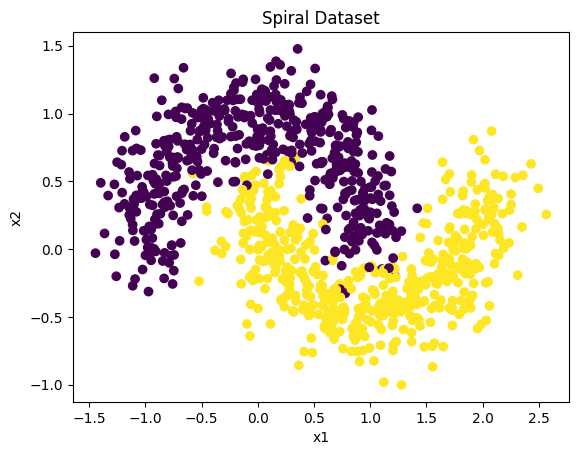

In [24]:
plt.scatter(df['x1'],df['x2'],c=df['target'])
plt.xlabel('x1')
plt.ylabel('x2')
plt.title("Spiral Dataset")
plt.show()

In [25]:
x=df[['x1','x2']]
y=df['target']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

#Scaling

In [26]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

#Build ANN

In [29]:
model =keras.Sequential([
    keras.layers.Dense(64,activation='relu',input_shape=(2,)),
    keras.layers.Dense(32,activation='relu'),
    keras.layers.Dense(16,activation='relu'),
    keras.layers.Dense(8,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Compile and train model

In [30]:
model.compile(optimizer='adam',loss='crossentropy',metrics=['accuracy'])

In [31]:
model.fit(x_train,y_train,epochs=20,validation_split=0.2)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.7953 - loss: 0.6412 - val_accuracy: 0.9062 - val_loss: 0.5782
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8484 - loss: 0.5233 - val_accuracy: 0.9000 - val_loss: 0.4237
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8562 - loss: 0.3822 - val_accuracy: 0.9187 - val_loss: 0.2748
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8656 - loss: 0.2980 - val_accuracy: 0.9187 - val_loss: 0.2179
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8687 - loss: 0.2739 - val_accuracy: 0.9187 - val_loss: 0.2047
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8813 - loss: 0.2623 - val_accuracy: 0.9250 - val_loss: 0.1985
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8750 - loss: 0.2521 - val_accuracy: 0.9250 - val_loss: 0.1883
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8938 - loss: 0.2324 - val_accuracy: 0.9250 - val_los

#Evaluate

In [32]:
model.evaluate(x_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9600 - loss: 0.1333  


[0.1333131194114685, 0.9599999785423279]

#Predict New Data

In [35]:
new_data=np.array([[0.5,0.5]])
new_data=scaler.transform(new_data)
prediction=model.predict(new_data)
print("Prediction Probability: ",prediction)
print("Final Class: ",(prediction>0.5).astype(int))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Prediction Probability:  [[0.12183386]]
Final Class:  [[0]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
